# 384-Well Plate: Clustering

This notebook tests whether wines from unsupervised groupings in spectral space, as an independent check on 03_384well_Analysis.ipynb`'s supervised LDA result. LDA is provided the labels, but the methods here are not. So, if wines that LDA separates well also cluster naturally, that's independent evidence the separation reflects real structure in the data.

Two Analyses: 
1. Silhouette score vs. Adjusted Rand Index, scanned across every wavelength — Checks one wavelength at a time, and a demonstration that "tight clusters" (silhouette) and "correct clusters" (agreement with true wine identity) are not the same thing.
2. Hierarchical clustering on the full compact feature vector — The more informative test, since it combines all 14 sensors rather than one wavelength at a time.

Files used from previous notebooks:
- master_df_384.csv (from 01_384well_Import.ipynb) — Needed for the per-wavelength scan, which requires the full spectral data, not the reduced compact vector.
- compact_matrix_384.csv (from 03_384well_Analysis.ipynb) - Needed for the hierarchical clustering section, so this notebook clusters on the same validated feature set the LDA analysis used. Baseline correction is recomputed locally, but the sensor/wavelength selection that built the compact vector is not re-derived here. It's loaded directly from 03_384well_Analysis.ipynb's output, so both notebooks are guaranteed to be working from the same feature set.

## Imports and data load

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

## 1. Baseline correction

Recomputed locally rather than loaded, since the per-wavelength scan needs the full spectral resolution, not just the compact vector.

In [5]:
master_df_384 = pd.read_csv("../../data/processed/master_df_384.csv")

control = master_df_384[master_df_384["Sensor"] == "Wine control"]
control_baseline = control.groupby(["Wine", "Wavelength"])["Absorbance"].mean().reset_index()
control_baseline = control_baseline.rename(columns = {"Absorbance": "Control_Absorbance"})

sensor_only = master_df_384[master_df_384["Sensor"] != "Wine control"]
corrected_all = sensor_only.merge(control_baseline, on = ["Wine", "Wavelength"], how = "left")
corrected_all["Corrected_Absorbance"] = corrected_all["Absorbance"] - corrected_all["Control_Absorbance"]

print(master_df_384.shape)
print(corrected_all.shape)

(260352, 8)
(227808, 10)


## 2. PCA + silhouette score across every wavelength

The wavelength scan in 03_384well_Analysis.ipynb used the F-statistic, which requires wine labels and therefore measures supervised discrimination. This section whether the 14-sensor feature vector forms well-separated clusters in PCA space at each wavelength and without reference to true identity. Silhouette score measures cluster cohesion and separation on a scale from -1 to 1, with higher values indicating tighter, more distinct clusters. Comparing the best wavelength by this unsupervised measure against the best wavelength by F-statistic tests whether supervised and unsupervised approaches agree on which wavelength carries the most structure. This section finds that they do not.

In [ ]:
silhouette_scores = []

for wavelength in sorted(master_df_384["Wavelength"].unique()):
    wl_data = corrected_all[corrected_all["Wavelength"] == wavelength]

    #Build a 72 x 14 matrix for this single wavelength (one column per sensor)
    wl_matrix = wl_data.pivot_table(
        index = ["Wine", "Replicate"],
        columns = "Sensor",
        values = "Corrected_Absorbance"
    )

    if wl_matrix.isnull().values.any() or wl_matrix.shape[1] < 2:
        continue

    X_wl = StandardScaler().fit_transform(wl_matrix)
    pca_wl = PCA(n_components = 2)
    scores_wl = pca_wl.fit_transform(X_wl)

    #Cluster into 12 groups (true number of wines) using KMeans, to compute a silhouette score - not the final clustering method
    kmeans = KMeans(n_clusters = 12, n_init = 10, random_state = 42)
    cluster_assignments = kmeans.fit_predict(scores_wl)

    sil = silhouette_score(scores_wl, cluster_assignments)
    silhouette_scores.append({"Wavelength": wavelength, "Silhouette": sil})

silhouette_df = pd.DataFrame(silhouette_scores)

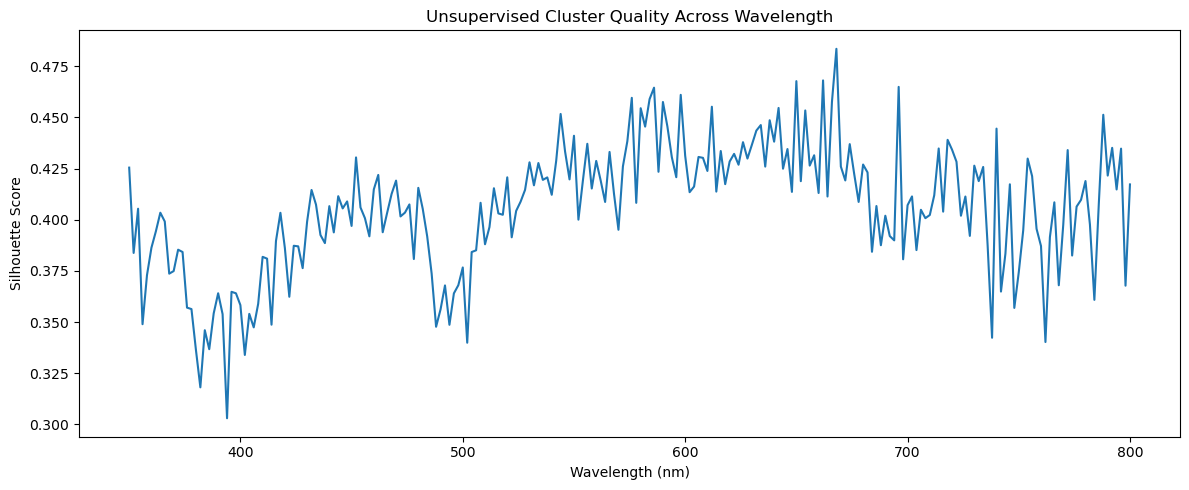

Wavelength    668.000000
Silhouette      0.483472
Name: 159, dtype: float64


In [7]:
plt.figure(figsize = (12, 5))
plt.plot(silhouette_df["Wavelength"], silhouette_df["Silhouette"])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Silhouette Score")
plt.title("Unsupervised Cluster Quality Across Wavelength")
plt.tight_layout()
plt.show()

best_silhouette_wavelength = silhouette_df.loc[silhouette_df["Silhouette"].idxmax()]
print(best_silhouette_wavelength)

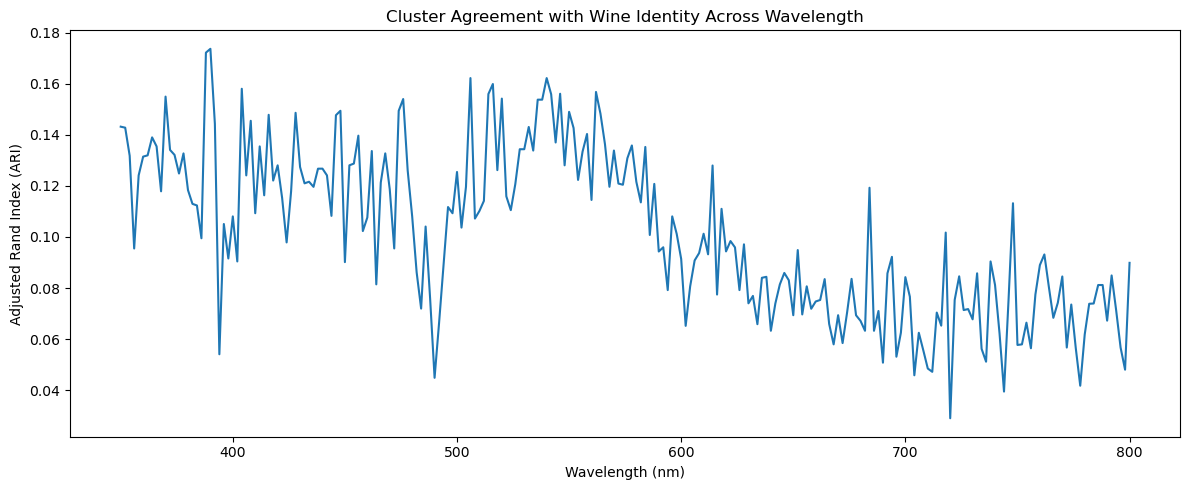

Wavelength    390.000000
ARI             0.173661
Name: 20, dtype: float64
     Wavelength       ARI
0           350  0.143178
159         668  0.057953


In [8]:
ari_scores = []

for wavelength in sorted(master_df_384["Wavelength"].unique()):
    wl_data = corrected_all[corrected_all["Wavelength"] == wavelength]
    wl_matrix = wl_data.pivot_table(index = ["Wine", "Replicate"], columns = "Sensor", values = "Corrected_Absorbance")

    if wl_matrix.isnull().values.any() or wl_matrix.shape[1] < 2:
        continue

    X_wl = StandardScaler().fit_transform(wl_matrix)
    pca_wl = PCA(n_components = 2)
    scores_wl = pca_wl.fit_transform(X_wl)

    kmeans = KMeans(n_clusters = 12, n_init = 10, random_state = 42)
    cluster_assignments = kmeans.fit_predict(scores_wl)

    true_wine_labels = wl_matrix.index.get_level_values("Wine")
    ari = adjusted_rand_score(true_wine_labels, cluster_assignments)

    ari_scores.append({"Wavelength": wavelength, "ARI": ari})

ari_df = pd.DataFrame(ari_scores)

plt.figure(figsize = (12, 5))
plt.plot(ari_df["Wavelength"], ari_df["ARI"])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Adjusted Rand Index (ARI)")
plt.title("Cluster Agreement with Wine Identity Across Wavelength")
plt.tight_layout()
plt.show()

print(ari_df.loc[ari_df["ARI"].idxmax()])
print(ari_df[ari_df["Wavelength"].isin([350, 668])])

Comparing cluster tightness (silhouette score) against actual agreement with wine identity (Adjusted Rand Index) reveals that these two measures diverge substantially across wavelength. The wavelength with the highest silhouette score (668nm, silhouette = 0.483) shows very poor agreement with true wine identity (ARI = 0.058), indicating that the tightest unsupervised clusters at this wavelength do not correspond to wine groupings and likely reflect an unrelated source of structure in the data. By contrast, the wavelength previously identified as most discriminating by the supervised F-statistic scan (350nm) shows substantially higher agreement with wine identity (ARI = 0.143), and sits within a broader region of elevated ARI spanning approximately 350-580nm. The true ARI maximum occurs at 390nm (ARI = 0.174), closely adjacent to the F-statistic peak, supporting the conclusion that this region of the spectrum carries genuine wine-discriminating information, independently corroborated by an unsupervised method. Absolute ARI values throughout this analysis remain modest (below 0.2), reflecting the considerably harder task of recovering 12-way wine identity from only two unsupervised PCA dimensions with no label information, compared to the 72.2% (unnested) and 73.6% (nested) accuracy achieved by supervised LDA using the full 14-dimensional feature space (03_384well_Analysis.ipynb, Section 7).

## 3. Hierarchical clustering

Tests whether wines naturally group according to spectral similarity on the compact feature vector, independent of the labelled classification approach used by LDA. Ward's method is used, which merges clusters to minimize the resulting increase in within-cluster variance at each step. This is a standard choice for continuous, standardized data. 

In [ ]:
#Loaded from 03_384well_Analysis.ipynb's output, so this notebook clusters on the same validated feature set the LDA analysis used

compact_matrix = pd.read_csv("../../data/processed/compact_matrix_384.csv")
compact_matrix = compact_matrix.set_index(["Wine", "Replicate"])
print(compact_matrix.shape)   # expect (72, 14)

(72, 14)


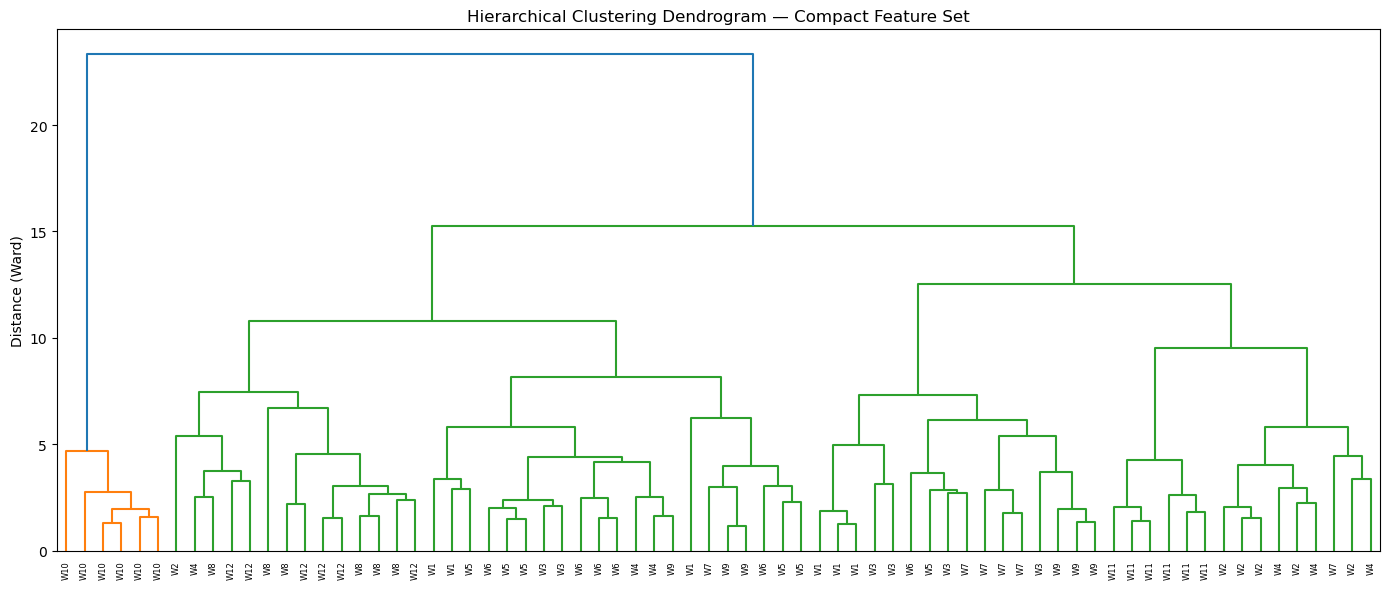

In [10]:
X_scaled = StandardScaler().fit_transform(compact_matrix)
linkage_matrix = linkage(X_scaled, method = "ward")

wine_labels_list = compact_matrix.index.get_level_values("Wine").tolist()

plt.figure(figsize = (14, 6))
dendrogram(linkage_matrix, labels = wine_labels_list, leaf_rotation = 90)
plt.title("Hierarchical Clustering Dendrogram — Compact Feature Set")
plt.ylabel("Distance (Ward)")
plt.tight_layout()
plt.show()

### Reading the dendrogram

The dendrogram displays a tree structure built by successively merging the two most similar samples or clusters, using Ward's method to decide which merge minimizes within-cluster variance at each step. Each of the 72 leaves at the bottom represents one (Wine, Replicate) sample. The y-axis shows the distance (dissimilarity) at which two branches were joined. The lower merge height means more similar and higher merge height means less similar.

Replicates of the same wine that are chemically consistent should merge with each other at low height, before merging with any other wine. This produces a tight, early-joining group of six leaves, visible for W10 (far left, orange) and W11 (its own tight group further right). Where a wine's six replicates instead merge with a different wine's replicates at a similarly low height — as seen for W2 and W4 — this indicates the two wines are not well-separated in this feature space. And that a classifier or clustering method has no strong basis to tell them apart.

The overall shape of the tree also carries information as it splits first into two very large, high-level branches (the leftmost W10 branch vs. everything else, joining at the very top around height ~23), meaning W10 is the single most distinct wine in the whole dataset. Below that, the remaining 11 wines gradually subdivide into smaller, less pure sub-groups, mirroring the moderate, partial separation seen throughout this dissertation's LDA, PCA, and silhouette/ARI analyses.

## 4. Cluster assignment and agreement with wine identity

Cutting the dendrogram at k=12 (the true number of wines) tests whether unsupervised clustering recovers the actual groupings without being told the labels. An unsupervised counterpart to the LDA classification in 03_384well_Analysis.ipynb, Section 7.

In [11]:
def wine_key(w):
    return int(w[1:])

wine_order = sorted(set(wine_labels_list), key = wine_key)

cluster_labels_12 = fcluster(linkage_matrix, t = 12, criterion = "maxclust")

cluster_df = pd.DataFrame({"Wine": wine_labels_list, "Cluster": cluster_labels_12})
agreement_table = pd.crosstab(cluster_df["Wine"], cluster_df["Cluster"])
agreement_table = agreement_table.reindex(wine_order)
print(agreement_table)

#Quantify overall agreement with true wine identity, same metric as the
#silhouette/ARI comparison above - keeps this section consistent with
#the earlier unsupervised evaluation
hier_ari = adjusted_rand_score(wine_labels_list, cluster_labels_12)
print(f"\nHierarchical clustering ARI (k=12): {hier_ari:.3f}")

Cluster  1   2   3   4   5   6   7   8   9   10  11  12
Wine                                                   
W1        0   0   0   0   2   0   1   3   0   0   0   0
W2        0   1   0   0   0   0   0   0   0   0   0   5
W3        0   0   0   0   2   0   0   2   1   1   0   0
W4        0   1   0   0   2   0   0   0   0   0   0   3
W5        0   0   0   0   3   2   0   0   1   0   0   0
W6        0   0   0   0   4   1   0   0   1   0   0   0
W7        0   0   0   0   0   1   0   0   1   3   0   1
W8        0   1   4   1   0   0   0   0   0   0   0   0
W9        0   0   0   0   1   2   0   0   0   3   0   0
W10       6   0   0   0   0   0   0   0   0   0   0   0
W11       0   0   0   0   0   0   0   0   0   0   6   0
W12       0   2   4   0   0   0   0   0   0   0   0   0

Hierarchical clustering ARI (k=12): 0.319


Hierarchical clustering achieves an ARI of 0.319 against true wine
identity — nearly double the best value obtained from any single
wavelength in the earlier unsupervised scan (0.174 at 390nm) — indicating
that combining information across all 14 sensors captures substantially
more wine-discriminating structure than any individual wavelength alone.

Cluster assignments show a similar pattern to the supervised LDA results
in `03_384well_Analysis.ipynb`, Section 7: W10 and W11 form entirely pure
clusters, with all six replicates of each isolated from every other wine,
consistent with their near-perfect LDA classification. W2 and W4, the
pair most frequently confused in the LDA confusion matrix, also share a
cluster under unsupervised hierarchical clustering (5 of 6 W2 replicates
and 3 of 6 W4 replicates in Cluster 12) — independent confirmation that
these two wines are not merely difficult for one specific classifier to
distinguish, but show genuine underlying chemical similarity in this
feature space. The remaining wines (W1, W3, W5, W6, W7, W9) are
distributed across multiple clusters each, indicating more substantial
chemical overlap among this subset than among the cleanly-resolved
wines.

In [ ]:
for wine in ["W1", "W2", "W4", "W6", "W7", "W10", "W11"]:
    clusters_for_wine = cluster_df[cluster_df["Wine"] == wine]["Cluster"].tolist()
    print(f"{wine}: clusters = {clusters_for_wine}")

W1: clusters = [5, 8, 7, 5, 8, 8]
W2: clusters = [12, 12, 12, 2, 12, 12]
W4: clusters = [12, 12, 5, 5, 2, 12]
W6: clusters = [6, 5, 5, 9, 5, 5]
W7: clusters = [6, 12, 9, 10, 10, 10]
W10: clusters = [1, 1, 1, 1, 1, 1]
W11: clusters = [11, 11, 11, 11, 11, 11]


## Summary

This notebook tested whether wines form natural, unsupervised groupings in spectral space, using three complimentary approaches on the compact 14-sensor feature vector established in 03_384well_Analysis.ipynb.

An unsupervised wavelength scan (PCA, KMeans, silhouette score) initially suggested 668nm as the wavelength with the tightest clusters. However, checking this against actual wine identity (Adjusted Rand Index) showed this wavelength's clusters had almost no correspondence to true wine groupings (ARI = 0.058). The clusters were tight, but not meaningful. The wavelength region previously identified by the supervised F-statistic scan (~350-390nm) showed much better agreement with wine identity (ARI up to 0.174), despite not having the single highest silhouette score. This demonstrates that cluster tightness and  correctness are distinct properties, and that silhouette score alone is not a reliable guide to which wavelength carries genuine wine-discriminating information for this dataset.

Hierarchical clustering using all 14 sensors together (rather than a single wavelength) achieved a substantially higher ARI of 0.319, nearly double the best single-wavelength result, confirming that combining information across sensors captures more wine-identity structure than any individual measurement. Cluster composition closely mirrored the supervised LDA results from 03_384well_Analysis.ipynb. Which were that W10 and W11 formed entirely pure, isolated clusters, consistent with their near-perfect LDA classification, while W2 and W4 — the pair most frequently confused by LDA — also shared a cluster under unsupervised clustering, independently confirming genuine chemical similarity between these two wines rather than a classifier-specific artifact.

Across 03_384well_Analysis.ipynb and this notebook, five independent analytical approaches (fixed-band F-statistic, full wavelength scan, PCA loadings, LDA classification, and hierarchical clustering) converge on a consistent picture. Certain wines (W10, W11) are highly distinctive, others (W2, W4) are genuinely difficult to separate regardless of method, and the ~350-390nm region of the spectrum consistently carries more wine-discriminating information.